In [15]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict
from dotenv import load_dotenv
import time

load_dotenv()

True

In [16]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    bpb: float
    boundary_percent: float
    summary: str

```mermaid
graph TD
    __start__ --> calculate_boundary_percent
    __start__ --> calculate_bpb
    __start__ --> calculate_sr

    calculate_boundary_percent --> summary
    calculate_bpb --> summary
    calculate_sr --> summary

    summary --> __end__

In [17]:
def calculate_strike_rate(state: BatsmanState) -> dict:
    balls = state.get("balls", 0)
    runs = state.get("runs", 0)

    strike_rate = (runs / balls * 100) if balls > 0 else 0.0

    # Sirf specific key return karen, pura state unpack na karen
    return {"strike_rate": round(strike_rate, 2)}

In [18]:
def calculate_bpb(state: BatsmanState) -> dict:
    balls = state.get("balls", 0)
    boundaries = state.get("fours", 0) + state.get("sixes", 0)

    # Division by zero safe guard
    bpb = (balls / boundaries) if boundaries > 0 else 0.0

    return {"bpb": round(bpb, 2)}

In [19]:
def calculate_boundary_percent(state: BatsmanState) -> dict:
    runs = state.get("runs", 0)
    fours = state.get("fours", 0)
    sixes = state.get("sixes", 0)

    boundary_runs = (fours * 4) + (sixes * 6)
    
    # Division by zero safe guard
    boundary_percent = (boundary_runs / runs * 100) if runs > 0 else 0.0

    return {"boundary_percent": round(boundary_percent, 2)}

In [20]:
def generate_summary(state: BatsmanState) -> dict:
    # Safe key extraction with default values
    sr = state.get("strike_rate", 0.0)
    bpb = state.get("bpb", 0.0)

    boundary_percent = state.get("boundary_percent", 0.0)

    summary_text = (
        f"Strike Rate: {sr}\n"
        f"Ball Per Boundary: {bpb}\n"
        f"Boundary Percentage: {boundary_percent}%"
    ).strip()

    return {"summary": summary_text}

In [21]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_strike_rate",calculate_strike_rate)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("calculate_boundary_percent",calculate_boundary_percent)
graph.add_node("generate_summary",generate_summary)


graph.add_edge(START,"calculate_strike_rate")
graph.add_edge(START,"calculate_bpb")
graph.add_edge(START,"calculate_boundary_percent")

graph.add_edge("calculate_strike_rate","generate_summary")
graph.add_edge("calculate_bpb","generate_summary")
graph.add_edge("calculate_boundary_percent","generate_summary")

graph.add_edge("generate_summary",END)

workflow = graph.compile()


In [22]:
initial_state: BatsmanState = {
    "runs": int(input("Enter Runs: ")),
    "balls": int(input("Enter Balls: ")),
    "fours": int(input("Enter Fours: ")),
    "sixes": int(input("Enter Sixes: "))
}

# Graph run karke output print karein
result = workflow.invoke(initial_state)
print("\n--- FINAL SUMMARY ---")
print(result["summary"])


--- FINAL SUMMARY ---
Strike Rate: 150.0
Ball Per Boundary: 5.0
Boundary Percentage: 62.22%


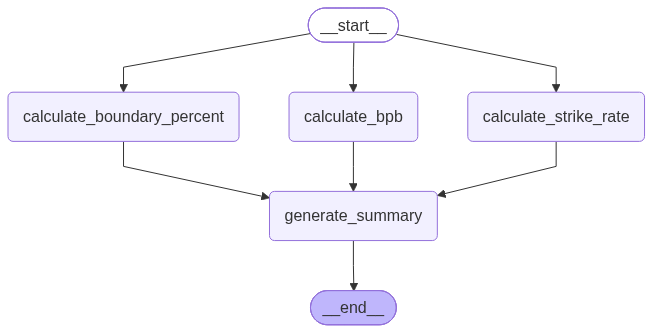

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())